# Ac-225: Comparing S-value equations/values

Formulating Ac-225 S-values as functions of tumor radius and mass

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

Cellular level tumor details

In [8]:
singleCell_ten_umDiam    = 10e-6   # m
singleCell_twenty_umDiam = 20e-6   # m
singleCell_fourteen_umDiam = 14e-6 # m
 
density_tumour = 1.05   # g/mL  (used throughout)
 
# Convert diameters → masses  (radius in cm for volume in mL)
tenUMcell_mass      = 4/3 * np.pi * (singleCell_ten_umDiam    / 2 * 1e2)**3 * density_tumour
twentyUMcell_mass   = 4/3 * np.pi * (singleCell_twenty_umDiam / 2 * 1e2)**3 * density_tumour
fourteenUMcell_mass = 4/3 * np.pi * (singleCell_fourteen_umDiam / 2 * 1e2)**3 * density_tumour
 
print(f"A single, spherical tumour cell translates to a mass of:\n"
      f"  ~{tenUMcell_mass:.2e} – {twentyUMcell_mass:.2e} g")

A single, spherical tumour cell translates to a mass of:
  ~5.50e-10 – 4.40e-09 g


In [9]:
# Ac-225 decay chain: alpha-particle tissue range 47–85 µm  (Miller, 2024)
minRange_Ac225 = 47e-6   # m
maxRange_Ac225 = 85e-6   # m
 
minRange_Ac225_mass = 4/3 * np.pi * (minRange_Ac225 * 1e2)**3 * density_tumour
maxRange_Ac225_mass = 4/3 * np.pi * (maxRange_Ac225 * 1e2)**3 * density_tumour
 
print(f"\nAlpha-decay particles start escaping beyond tumours of:\n"
      f"  ~{maxRange_Ac225_mass:.2e} g  (85 µm radius)")


Alpha-decay particles start escaping beyond tumours of:
  ~2.70e-06 g  (85 µm radius)


**Olguin et al. (2020): Ac-225 S-values (macro-scale)**

Reporting data points for Ac-225 decay in 100% soft tissue

In [10]:
olguin_tumor_mass_g = np.array([
    0.0043145, 0.014561, 0.034516, 0.11649, 0.27613,
    0.53931,   0.93192,  2.209,    4.3145,  14.5613,
    34.5156,   116.4903, 276.1251, 539.3067, 931.922
])
 
olguin_225Ac_sValue_GyBqS = np.array([
    2.17e-07, 6.46e-08, 2.73e-08, 8.10e-09, 3.42e-09,
    1.75e-09, 1.02e-09, 4.28e-10, 2.19e-10, 6.50e-11,
    2.74e-11, 8.14e-12, 3.43e-12, 1.76e-12, 1.02e-12
])
 
# Convert Gy/Bq/s  →  mGy/MBq/h
olguin_225Ac_sValue_mGyMBqH = olguin_225Ac_sValue_GyBqS * 3.6e12

**Ac-225 power-law equation (Olguin et al., 2020)**

Each nuclide $i$ in the decay chain follows a two-term power law:

$$S(m, i) = A_{i,\mathrm{high}} \cdot \left(\frac{m}{\rho}\right)^{B_{i,\mathrm{high}}} + A_{i,\mathrm{low}} \cdot \left(\frac{m}{\rho}\right)^{B_{i,\mathrm{low}}}$$

The decay chain follows: <sup>225</sup>Ac → <sup>221</sup>Fr → <sup>217</sup>At → <sup>213</sup>Bi → <sup>213</sup>Po → <sup>209</sup>Ti → <sup>209</sup>Pb → <sup>209</sup>Bi

In [11]:
N = 10000
tumorMass = np.logspace(np.log10(0.0043145), np.log10(931.922), N)
 
def olguin_sValue(m, A_high, B_high, A_low=0, B_low=0, unit_conv=1):
    """
    Generic two-term Olguin power law.
    unit_conv: multiply result by this factor (e.g. 3.6e12 for Gy/Bq/s → mGy/MBq/h).
    If A_low / B_low are 0, returns a single-term power law.
    """
    return (A_high * (m / density_tumour)**B_high
            + A_low  * (m / density_tumour)**B_low) * unit_conv
 
# Ac-225 (already in mGy/MBq/h in the original equations)
Olguin_sValue_Ac225 = (
    3.29e3 * (tumorMass / density_tumour)**(-0.999)
    + 14.8  * (tumorMass / density_tumour)**(-0.986)
)
 
# Daughters (coefficients in Gy/Bq/s → convert with ×3.6e12)
Olguin_sValue_Fr221 = olguin_sValue(tumorMass, 9.94e-10, -0.999, 1.58e-12, -0.960, 3.6e12)
Olguin_sValue_At217 = olguin_sValue(tumorMass, 1.11e-10, -0.999, 1.19e-14, -0.961, 3.6e12)
Olguin_sValue_Bi213 = olguin_sValue(tumorMass, 1.80e-11, -0.999, 5.28e-11, -0.937, 3.6e12)
Olguin_sValue_Po213 = olguin_sValue(tumorMass, 1.32e-9,  -0.998, 2.50e-16, -0.796, 3.6e12)
Olguin_sValue_Ti209 = olguin_sValue(tumorMass, 7.69e-11, -0.887, unit_conv=3.6e12)
Olguin_sValue_Pb209 = olguin_sValue(tumorMass, 2.80e-11, -0.978, unit_conv=3.6e12)
 
# Sum over Ac-225 + all daughters
Olguin_total_sValue = (
    Olguin_sValue_Ac225 + Olguin_sValue_Fr221 + Olguin_sValue_At217
    + Olguin_sValue_Bi213 + Olguin_sValue_Po213
    + Olguin_sValue_Ti209 + Olguin_sValue_Pb209
)

Plot of Ac-225 and daughters

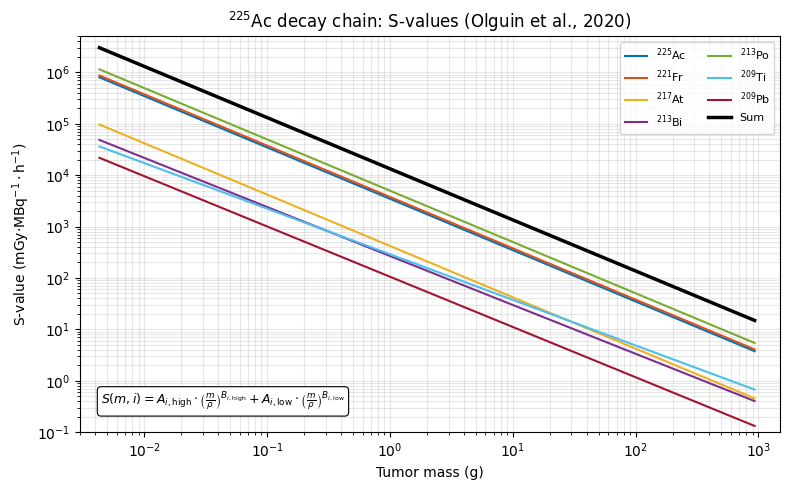

In [12]:
plotColor = [
    (0.0000, 0.4470, 0.7410),   # blue
    (0.8500, 0.3250, 0.0980),   # orange
    (0.9290, 0.6940, 0.1250),   # yellow
    (0.4940, 0.1840, 0.5560),   # purple
    (0.4660, 0.6740, 0.1880),   # green
    (0.3010, 0.7450, 0.9330),   # cyan
    (0.6350, 0.0780, 0.1840),   # dark red
]
 
lineWidth_daughter = 1.5
fig, ax = plt.subplots(figsize=(8, 5))
 
daughters = [
    (Olguin_sValue_Ac225, r"$^{225}$Ac",  plotColor[0]),
    (Olguin_sValue_Fr221, r"$^{221}$Fr",  plotColor[1]),
    (Olguin_sValue_At217, r"$^{217}$At",  plotColor[2]),
    (Olguin_sValue_Bi213, r"$^{213}$Bi",  plotColor[3]),
    (Olguin_sValue_Po213, r"$^{213}$Po",  plotColor[4]),
    (Olguin_sValue_Ti209, r"$^{209}$Ti",  plotColor[5]),
    (Olguin_sValue_Pb209, r"$^{209}$Pb",  plotColor[6]),
]
 
for sVal, lbl, col in daughters:
    ax.loglog(tumorMass, sVal, color=col, linewidth=lineWidth_daughter, label=lbl)
 
ax.loglog(tumorMass, Olguin_total_sValue, 'k-', linewidth=2.5, label="Sum")
 
eqnStr = (r"$S(m,i) = A_{i,\mathrm{high}} "
          r"\cdot \left(\frac{m}{\rho}\right)^{B_{i,\mathrm{high}}} "
          r"+ A_{i,\mathrm{low}} "
          r"\cdot \left(\frac{m}{\rho}\right)^{B_{i,\mathrm{low}}}$")
 
ax.text(0.03, 0.05, eqnStr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=0.8))
 
ax.set_xlabel("Tumor mass (g)")
ax.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax.set_title(r"$^{225}$Ac decay chain: S-values (Olguin et al., 2020)")
ax.set_xlim([3e-3, 1.5e3])
ax.set_ylim([1e-1, 5e6])
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

**Lee (2022): micro-scale dosimetry of Ac-225**

The data exhibits a sigmoidal growth curve that approaches an asymptote near the maximum alpha-decay range (~85 µm). A logistic function is fit to describe the absorbed dose as a function of tumour radius:

$$D(r) = \frac{2.06}{1 + 5.38 \cdot e^{-6.84 \times 10^4 \cdot r}}$$

where $r$ is in metres and $D$ is in Gy.

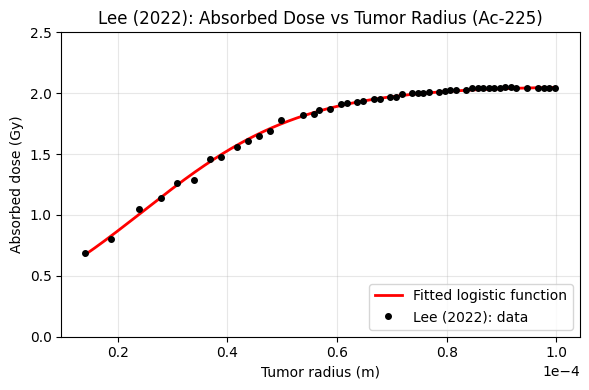

In [13]:
# Digitised data: absorbed dose (Gy) vs tumour radius (µm)
 
Lee_Ac225_radius_um = np.array([
    14.050689, 18.840,  23.810,  27.840,  30.830,  33.820,  36.790,  38.770,
    41.790,    43.730,  45.790,  47.760,  49.700,  53.710,  55.720,  56.760,
    58.710,    60.740,  61.730,  63.650,  64.700,  66.670,  67.780,  69.640,
    70.750,    71.790,  73.590,  74.700,  75.720,  76.740,  78.600,  79.610,
    80.600,    81.710,  83.600,  84.650,  85.640,  86.660,  87.640,  88.660,
    89.650,    90.640,  91.630,  92.710,  94.660,  96.670,  97.690,  98.680,  99.690
])
 
Lee_Ac225_gy = np.array([
    0.69, 0.80, 1.05, 1.14, 1.26, 1.29, 1.46, 1.48,
    1.56, 1.61, 1.65, 1.69, 1.78, 1.82, 1.83, 1.86,
    1.87, 1.91, 1.92, 1.93, 1.94, 1.95, 1.95, 1.97,
    1.97, 1.99, 2.00, 2.00, 2.00, 2.01, 2.01, 2.02,
    2.03, 2.03, 2.03, 2.04, 2.04, 2.04, 2.04, 2.04,
    2.04, 2.05, 2.05, 2.04, 2.04, 2.04, 2.04, 2.04, 2.04
])
 
# Logistic fit to sigmoidal absorbed-dose curve:
#   D(r) = 2.06 / (1 + 5.38 · exp(−6.84×10⁴ · r))   [r in metres]
radius_ac225_um = np.linspace(14, 100, 1000)
radius_ac225_m  = radius_ac225_um * 1e-6
 
Lee_absorbedDose = 2.06 / (1 + 5.38 * np.exp(-6.84e4 * radius_ac225_m))
 
plt.figure(figsize=(6, 4))
plt.plot(radius_ac225_m, Lee_absorbedDose, 'r-', linewidth=2, label="Fitted logistic function")
plt.plot(Lee_Ac225_radius_um * 1e-6, Lee_Ac225_gy, 'k.', markersize=8, label="Lee (2022): data")
plt.xlabel("Tumor radius (m)")
plt.ylabel("Absorbed dose (Gy)")
plt.title("Lee (2022): Absorbed Dose vs Tumor Radius (Ac-225)")
plt.ylim([0, 2.5])
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
ax = plt.gca()
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()

**Lee (2022): S-value as a function of mass**

The logistic absorbed-dose relationship can be re-expressed as an S-value by substituting $r(m) = \left(\frac{3m}{4\pi\rho}\right)^{1/3}$:

$$S_{\mathrm{Lee}}(m) = \frac{1.44 \times 10^4 \cdot \rho}{m \cdot \left[1 + 5.38 \cdot e^{-424.3 \cdot (m/\rho)^{1/3}}\right]}$$

where $m$ is the tumour mass in grams and $\rho = 1.05$ g/mL.

In [14]:
Lee_tumourMass = np.logspace(np.log10(1.21e-8), np.log10(4.40e-6), N)
 
def Lee_sValue(m):
    return (1.44e4 * density_tumour) / (
        m * (1 + 5.38 * np.exp(-424.3 * (m / density_tumour)**(1/3)))
    )
 
Lee_Ac225_sValue_mGyMBqH = Lee_sValue(Lee_tumourMass)
 
# Theoretical S-value limit:  S_max = E_avg / m
#   E_avg(Ac-225 chain) ≈ 28.7 MeV total; 576.72 is unit-conversion factor
tumorMass_fullRange = np.logspace(np.log10(1.5086e-9), np.log10(1e4), N)
S_theoretical_limit = (576.72 * 28.7) / tumorMass_fullRange

**Comparing S-value equations**

The Olguin (2020) and Lee (2022) relationships are compared across the full mass range. The theoretical S-value upper limit assumes complete deposition of all emitted decay-chain energy within the tumour.

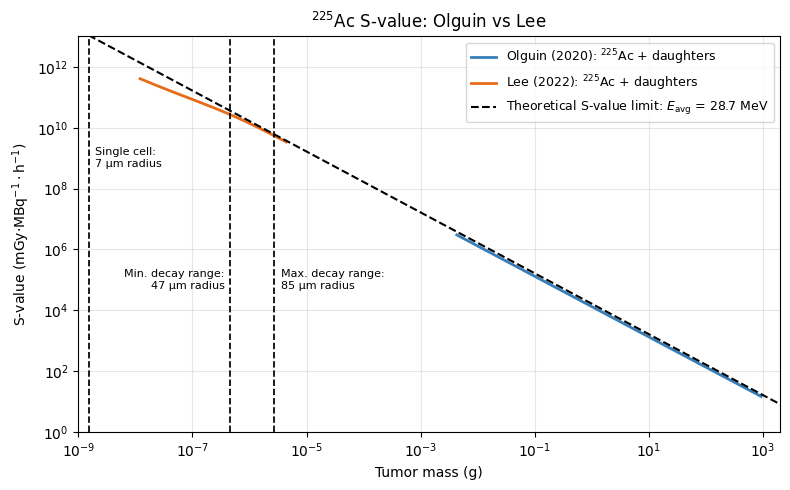

In [18]:
studyColor = [
    (0.9020, 0.4235, 0.1000),   # red-orange  → Lee
    (0.2157, 0.4941, 0.7216),   # blue        → Olguin
]
 
fig, ax = plt.subplots(figsize=(8, 5))
 
ax.loglog(tumorMass, Olguin_total_sValue,
          color=studyColor[1], linewidth=2,
          label=r"Olguin (2020): $^{225}$Ac + daughters")
 
ax.loglog(Lee_tumourMass, Lee_Ac225_sValue_mGyMBqH,
          color=studyColor[0], linewidth=2,
          label=r"Lee (2022): $^{225}$Ac + daughters")
 
ax.loglog(tumorMass_fullRange, S_theoretical_limit,
          'k--', linewidth=1.5,
          label=r"Theoretical S-value limit: $E_\mathrm{avg}$ = 28.7 MeV")
 
# Vertical reference lines
yHigh, yLow = 1e9, 1e5
 
ax.axvline(fourteenUMcell_mass, color='k', linestyle='--', linewidth=1.25)
ax.text(fourteenUMcell_mass * 1.3, yHigh,
        "Single cell:\n7 µm radius",
        ha='left', va='center', fontsize=8)
 
ax.axvline(maxRange_Ac225_mass, color='k', linestyle='--', linewidth=1.25)
ax.text(maxRange_Ac225_mass * 1.3, yLow,
        "Max. decay range:\n85 µm radius",
        ha='left', va='center', fontsize=8)
 
ax.axvline(minRange_Ac225_mass, color='k', linestyle='--', linewidth=1.25)
ax.text(minRange_Ac225_mass * 0.8, yLow,
        "Min. decay range:\n47 µm radius",
        ha='right', va='center', fontsize=8)
 
ax.set_xlabel("Tumor mass (g)")
ax.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax.set_title(r"$^{225}$Ac S-value: Olguin vs Lee")
ax.set_xlim([1e-9, 2e3])
ax.set_ylim([1e0, 1e13])
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Creating a single formalism from micro- to macroscopic tumors**

To link the S-values at the micro- and macro-scale tumor sizes, the Lee (2022) equation informs the micro-scale and the Olguin (2020) equation informs the macro-scale. They are joined using a logistic transition function:

$$LT(m) = \left( 1 + \left( \frac{m_T}{m} \right)^k \right)^{-1}$$

$$S_{^{225}\mathrm{Ac}\rightarrow^{209}\mathrm{Bi}}(m) = \left(1 - LT(m)\right) \cdot S_{\mathrm{Lee}}(m) + LT(m) \cdot S_{\mathrm{Olguin}}(m)$$

where $m_T$ is the transition mass at which both formulas contribute equally, and $k$ controls the sharpness of the transition.

In [19]:
# Mass range
mass_smooth = np.logspace(np.log10(1.5e-9), 3, 4000)
 
# Transition mass (Lee ↔ Olguin cross-over)
m12 = 5.04257e-7   # g
k   = 4            # logistic sharpness
 
# Component functions (defined as lambdas for clarity)
def Lee_Ac225_smooth(m):
    return (1.44e4 * density_tumour) / (
        m * (1 + 5.38 * np.exp(-424.3 * (m / density_tumour)**(1/3)))
    )
 
def Olguin_Ac225_smooth(m):
    v = m / density_tumour
    return (
        3.29e3 * v**(-0.999) + 14.8  * v**(-0.986)                              # Ac-225
        + (9.94e-10 * v**(-0.999) + 1.58e-12 * v**(-0.960)) * 3.6e12           # Fr-221
        + (1.11e-10 * v**(-0.999) + 1.19e-14 * v**(-0.961)) * 3.6e12           # At-217
        + (1.80e-11 * v**(-0.999) + 5.28e-11 * v**(-0.937)) * 3.6e12           # Bi-213
        + (1.32e-9  * v**(-0.998) + 2.50e-16 * v**(-0.796)) * 3.6e12           # Po-213
        + (7.69e-11 * v**(-0.887))                           * 3.6e12           # Ti-209
        + (2.80e-11 * v**(-0.978))                           * 3.6e12           # Pb-209
    )
 
# Logistic transition
T12 = 1 / (1 + (m12 / mass_smooth)**k)
 
# Blended S-value
sValue_Ac225_smooth = (1 - T12) * Lee_Ac225_smooth(mass_smooth) + T12 * Olguin_Ac225_smooth(mass_smooth)

Transition weighting

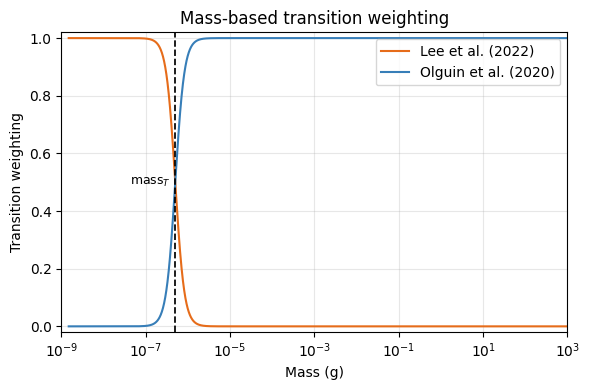

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
 
ax.semilogx(mass_smooth, 1 - T12,
            color=studyColor[0], linewidth=1.5, label="Lee et al. (2022)")
ax.semilogx(mass_smooth, T12,
            color=studyColor[1], linewidth=1.5, label="Olguin et al. (2020)")
 
ax.axvline(m12, color='k', linestyle='--', linewidth=1.25)
ax.text(m12 * 0.8, 0.5, r"mass$_T$", ha='right', va='center', fontsize=9)
 
ax.set_xlabel("Mass (g)")
ax.set_ylabel("Transition weighting")
ax.set_title("Mass-based transition weighting")
ax.set_xlim([1e-9, 1e3])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Plotting the smooth, multi-scale curve against data-informed relationshipsPlot: smooth multi-scale S-value vs all reference curves**

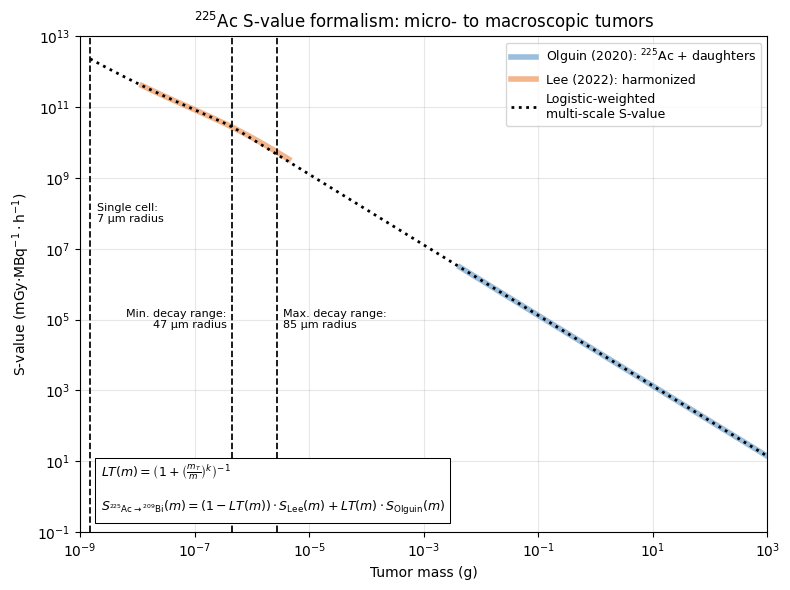

In [21]:
lineWidth_studies = 4
alphaVal          = 0.5

fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(tumorMass, Olguin_total_sValue,
          linestyle='-', color=(*studyColor[1], alphaVal),
          linewidth=lineWidth_studies,
          label=r"Olguin (2020): $^{225}$Ac + daughters")
ax.loglog(Lee_tumourMass, Lee_Ac225_sValue_mGyMBqH,
          linestyle='-', color=(*studyColor[0], alphaVal),
          linewidth=lineWidth_studies,
          label="Lee (2022): harmonized")
ax.loglog(mass_smooth, sValue_Ac225_smooth,
          'k:', linewidth=2,
          label="Logistic-weighted\nmulti-scale S-value")

eqnStr = (
    r"$LT(m) = \left( 1 + \left( \frac{m_T}{m} \right)^k \right)^{-1}$"
    "\n\n"
    r"$S_{^{225}\mathrm{Ac}\rightarrow^{209}\mathrm{Bi}}(m) = "
    r"(1-LT(m)) \cdot S_{\mathrm{Lee}}(m) + LT(m) \cdot S_{\mathrm{Olguin}}(m)$"
)
ax.text(0.03, 0.03, eqnStr, transform=ax.transAxes,
        fontsize=9, va='bottom', ha='left',
        bbox=dict(facecolor='white', edgecolor='black', linewidth=0.75))

ax.axvline(fourteenUMcell_mass,   color='k', linestyle='--', linewidth=1.25)
ax.text(fourteenUMcell_mass * 1.3,  1e8, "Single cell:\n7 \u03bcm radius",
        ha='left', va='center', fontsize=8)
ax.axvline(maxRange_Ac225_mass, color='k', linestyle='--', linewidth=1.25)
ax.text(maxRange_Ac225_mass * 1.3, 1e5, "Max. decay range:\n85 \u03bcm radius",
        ha='left', va='center', fontsize=8)
ax.axvline(minRange_Ac225_mass, color='k', linestyle='--', linewidth=1.25)
ax.text(minRange_Ac225_mass * 0.8, 1e5, "Min. decay range:\n47 \u03bcm radius",
        ha='right', va='center', fontsize=8)

ax.set_xlabel("Tumor mass (g)")
ax.set_ylabel(r"S-value (mGy$\cdot$MBq$^{-1}\cdot$h$^{-1}$)")
ax.set_title(r"$^{225}$Ac S-value formalism: micro- to macroscopic tumors")
ax.set_xlim([1e-9, 1e3])
ax.set_ylim([1e-1, 1e13])
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()